In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="pastel")
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, 
                             RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE

In [5]:
# Load dataset
df = pd.read_csv("heart-disease.csv")
print("Heart Disease Dataset")

display(df.head())

Heart Disease Dataset


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



🔎 Class Distribution Analysis:


/var/folders/lj/j7pqdxkj6fx42n8vf0xfsp9r0000gn/T/ipykernel_23154/2189448788.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values,


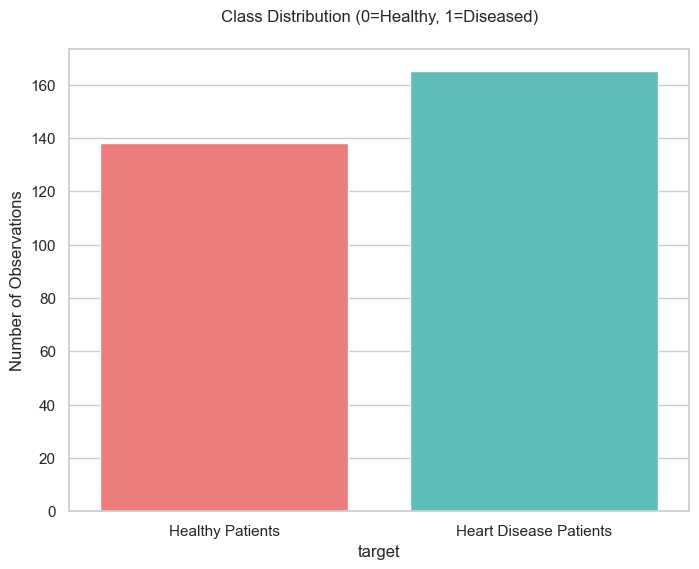

In [6]:
# Class distribution analysis
print("\n🔎 Class Distribution Analysis:")
class_distribution = df['target'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, 
            palette=["#FF6B6B", "#4ECDC4"])
plt.title("Class Distribution (0=Healthy, 1=Diseased)", pad=20)
plt.xticks([0, 1], ["Healthy Patients", "Heart Disease Patients"])
plt.ylabel("Number of Observations")
plt.show()

In [9]:
X = df.drop("target", axis=1)
y = df["target"]
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Class Balancing Results:")
print(f"Original distribution: {pd.Series(y).value_counts().to_dict()}")
print(f"Balanced distribution: {pd.Series(y_balanced).value_counts().to_dict()}")

Class Balancing Results:
Original distribution: {1: 165, 0: 138}
Balanced distribution: {1: 165, 0: 165}


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.2, 
    random_state=42
)

In [11]:
# Model pipeline configuration
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    "Random Forest": RandomForestClassifier(random_state=42)
}


In [22]:
# Model training and evaluation
print("Training Machine Learning Models...")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = {
        "model": model,
        "accuracy": model.score(X_test, y_test)
    }
    print(f"{name}: Accuracy = {results[name]['accuracy']:.2f}")

Training Machine Learning Models...
Logistic Regression: Accuracy = 0.79
KNN: Accuracy = 0.74
Random Forest: Accuracy = 0.83


In [23]:
# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
best_model = max(results, key=lambda x: results[x]['accuracy'])

In [24]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    results[best_model]['model'], X_test, y_test,
    ax=axes[0,0], cmap="Blues", colorbar=False
)
axes[0,0].set_title(f"Confusion Matrix ({best_model})")


Text(0.5, 1.0, 'Confusion Matrix (Random Forest)')

In [25]:
# ROC Curve
RocCurveDisplay.from_estimator(
    results[best_model]['model'], X_test, y_test,
    ax=axes[0,1], color="#FF6B6B"
)
axes[0,1].set_title("ROC Curve")


Text(0.5, 1.0, 'ROC Curve')

In [26]:
# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    results[best_model]['model'], X_test, y_test,
    ax=axes[1,0], color="#4ECDC4"
)
axes[1,0].set_title("Precision-Recall Curve")

Text(0.5, 1.0, 'Precision-Recall Curve')

/var/folders/lj/j7pqdxkj6fx42n8vf0xfsp9r0000gn/T/ipykernel_23154/4140640175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


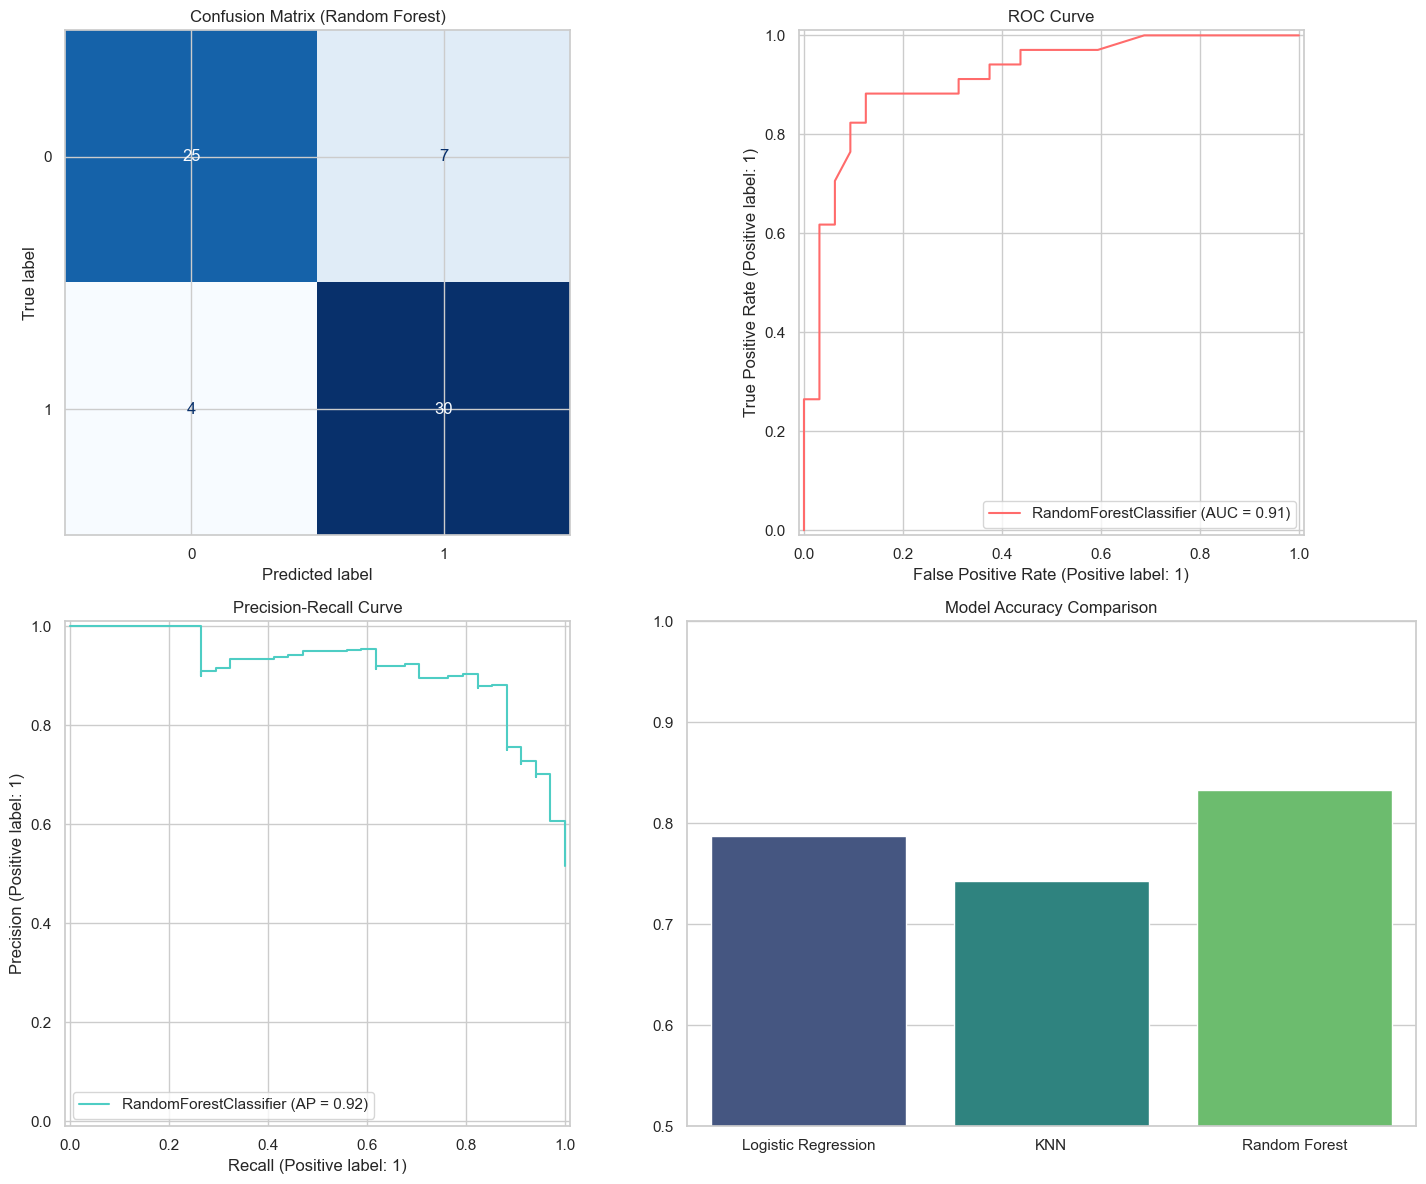

In [27]:
# Model comparison
sns.barplot(
    x=list(results.keys()),
    y=[results[m]['accuracy'] for m in results],
    palette="viridis",
    ax=axes[1,1]
)
axes[1,1].set_title("Model Accuracy Comparison")
axes[1,1].set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


In [28]:
# Final report
print("\n🏆 Final Classification Report:")
best_model_instance = results[best_model]['model']
y_pred = best_model_instance.predict(X_test)
print(classification_report(y_test, y_pred))


🏆 Final Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        32
           1       0.81      0.88      0.85        34

    accuracy                           0.83        66
   macro avg       0.84      0.83      0.83        66
weighted avg       0.84      0.83      0.83        66



In [29]:
import joblib

joblib.dump(best_model_instance, "heart_disease_prediction.joblib")

['heart_disease_prediction.joblib']